In [76]:
from zfish._io import import12chFlt, importSuite2p
import numpy as np
import matplotlib.pyplot as plt
from zfish.utils import *

dirname = r"D:\EnData\PlaceCell\Test\20251007\Fish 1\session 2\combined"

data = importSuite2p(dirname)

res = import12chFlt(r"D:\EnData\PlaceCell\Test\20251007\Fish 1\session 2\res.12chFlt")
print(res['behav_time'].max())

770.0166666666667


452.77918567325565
(5901, 2)
(2754, 670)
(2754, 670)


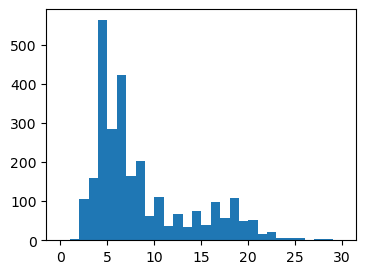

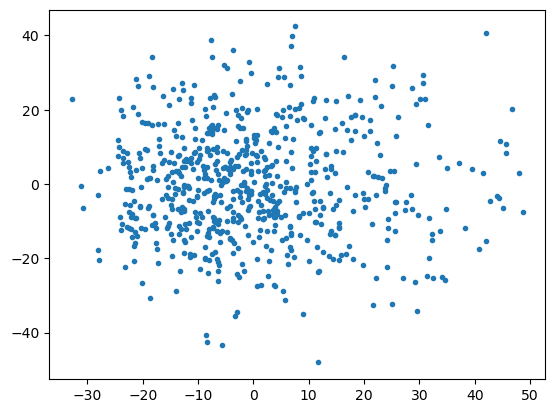

In [75]:
raw_traces = data['spks']
image_time_total = data['spks'].shape[1]/data['ops'].item()['fs']
print(image_time_total)
image_time = np.linspace(0, image_time_total, data['spks'].shape[1]+1)[:-1]
is_cell = data['iscell']
is_cell_idx = np.where(is_cell[:, 0] == 1)[0]
print(is_cell.shape)
raw_traces = raw_traces[is_cell_idx, :]
print(raw_traces.shape)
fig = plt.figure(figsize=(4, 3))

from sklearn.decomposition import PCA

std = np.std(raw_traces, axis=1)
spikes = np.where(raw_traces-std[:, np.newaxis]*3 >= 0, 1, 0)
print(spikes.shape)
plt.hist(np.mean(spikes, axis=1)*image_time_total, bins=30, range=(0, 30))
plt.show()

pca = PCA(n_components=10)
reduced_data = pca.fit_transform(raw_traces.T)
plt.plot(reduced_data[:, 0], reduced_data[:, 1], '.')